# 🧪 PySpark & SDP Medallion Playground

Este notebook roda nativamente dentro do container Docker do ambiente **Estudos SDP** com acesso completo ao **Apache Spark 4.1.3**, **Spark Connect**, **Apache Iceberg** e **Apache Kafka**.

In [1]:
from pyspark.sql import SparkSession, DataFrame
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType

# Conectando à sessão ativa do Spark Connect no cluster Docker
spark = SparkSession.builder \
    .remote("sc://spark-connect:15002") \
    .getOrCreate()

print("✅ Conectado com sucesso ao Spark Connect!")
spark.sql("SHOW TABLES IN local.dbo").toPandas()

✅ Conectado com sucesso ao Spark Connect!


,namespace,tableName,isTemporary
0,dbo,bronze_vendas_batch,False
1,dbo,gold_resumo_diario_vendas,False
2,dbo,gold_desempenho_canais,False
3,dbo,bronze_vendas_kafka,False
4,dbo,silver_vendas_batch,False
5,dbo,silver_vendas_kafka,False
6,dbo,silver_vendas_unificadas,False


## 🥉 1. Consulta das Tabelas Bronze (Database: `dbo`)
Exibe os dados brutos de vendas provenientes do arquivo CSV e do streaming Kafka.

In [6]:
print("--- 🥉 dbo.bronze_vendas_batch ---")
spark.table("local.dbo.bronze_vendas_batch").show(10, truncate=False)

if spark.catalog.tableExists("local.dbo.bronze_vendas_kafka"):
    print("--- 🥉 dbo.bronze_vendas_kafka ---")
    spark.table("local.dbo.bronze_vendas_kafka").show(10, truncate=False)

--- 🥉 dbo.bronze_vendas_batch ---
+--------+-------------------+----------+------------------+-----------+-------+----------+-----------+-------------------------+---------+
|id_venda|data_venda         |cliente_id|produto           |categoria  |valor  |quantidade|canal_venda|_ingestion_time          |_source  |
+--------+-------------------+----------+------------------+-----------+-------+----------+-----------+-------------------------+---------+
|VND-1001|2026-07-20 10:15:00|CLI-001   |Teclado Mecanico  |Perifericos|250.0  |1         |Loja_Fisica|2026-07-23 19:56:33.14606|BATCH_CSV|
|VND-1002|2026-07-20 11:30:00|CLI-002   |Mouse Sem Fio     |Perifericos|85.5   |2         |E-commerce |2026-07-23 19:56:33.14606|BATCH_CSV|
|VND-1003|2026-07-20 14:22:00|CLI-003   |Monitor 4K 27     |Monitores  |1899.99|1         |E-commerce |2026-07-23 19:56:33.14606|BATCH_CSV|
|VND-1004|2026-07-21 09:05:00|CLI-004   |Cadeira Ergonomica|Mobiliario |1250.0 |1         |Loja_Fisica|2026-07-23 19:56:33.146

## 🥈 2. Consulta da Camada Silver Unificada (Database: `dbo`)
Exibe as vendas consolidadas e higienizadas de todas as origens.

In [7]:
df_silver = spark.table("local.dbo.silver_vendas_unificadas")
print(f"📊 Total de vendas unificadas na Silver: {df_silver.count()}")
df_silver.orderBy(F.col("data_venda").desc()).show(10)

📊 Total de vendas unificadas na Silver: 21
+--------+-------------------+----------+------------------+-----------+--------------+----------+----------------+-----------+--------------------+---------------+
|id_venda|         data_venda|cliente_id|           produto|  categoria|valor_unitario|quantidade|valor_total_item|canal_venda|     _ingestion_time|        _source|
+--------+-------------------+----------+------------------+-----------+--------------+----------+----------------+-----------+--------------------+---------------+
|VND-1012|2026-07-23 18:10:00|   CLI-001|      Mousepad XXL|PERIFERICOS|          65.0|         1|            65.0| E-COMMERCE|2026-07-23 19:56:...|      BATCH_CSV|
|VND-2967|2026-07-23 16:56:31|   CLI-457|    Webcam Full HD|PERIFERICOS|         350.0|         1|           350.0| APP_MOBILE|2026-07-23 19:56:...|STREAMING_KAFKA|
|VND-2725|2026-07-23 16:56:27|   CLI-621|    Monitor 27 IPS|  MONITORES|        1400.0|         1|          1400.0| APP_MOBILE|2026-

## 🥇 3. Datamarts Gold & Análise Gráfica com Pandas e Matplotlib

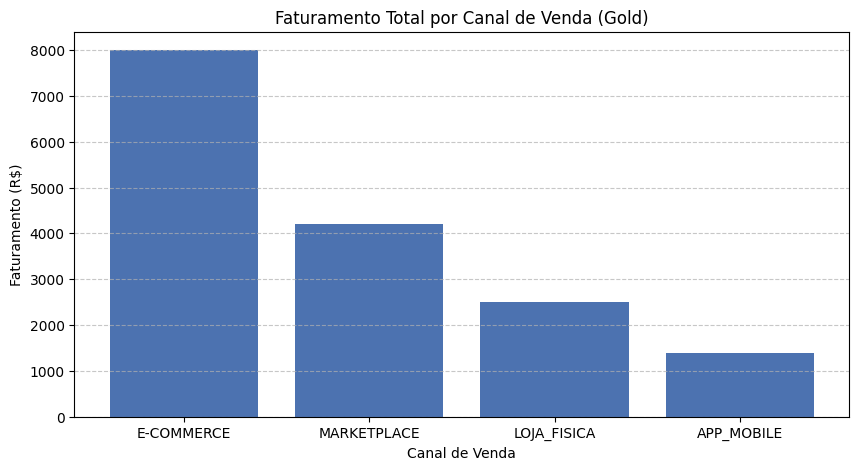

In [8]:
import matplotlib.pyplot as plt

# Convertendo o Datamart Gold para Pandas DataFrame
df_gold_canal = spark.table("local.dbo.gold_desempenho_canais").toPandas()

plt.figure(figsize=(10, 5))
plt.bar(df_gold_canal['canal_venda'], df_gold_canal['faturamento_total'], color='#4C72B0')
plt.title('Faturamento Total por Canal de Venda (Gold)')
plt.xlabel('Canal de Venda')
plt.ylabel('Faturamento (R$)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
# Verificar as tabela unificada

df_kafka = spark.sql("SELECT * FROM local.dbo.silver_vendas_kafka").toPandas()
df_batch = spark.sql("SELECT * FROM local.dbo.silver_vendas_batch").toPandas()

df_batch

,id_venda,data_venda,cliente_id,produto,categoria,valor_unitario,quantidade,valor_total_item,canal_venda,_ingestion_time,_source
0,VND-1001,2026-07-20 10:15:00,CLI-001,Teclado Mecanico,PERIFERICOS,250.00,1,250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
1,VND-1002,2026-07-20 11:30:00,CLI-002,Mouse Sem Fio,PERIFERICOS,85.50,2,171.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
2,VND-1003,2026-07-20 14:22:00,CLI-003,Monitor 4K 27,MONITORES,1899.99,1,1899.99,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
3,VND-1004,2026-07-21 09:05:00,CLI-004,Cadeira Ergonomica,MOBILIARIO,1250.00,1,1250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
4,VND-1005,2026-07-21 16:45:00,CLI-005,Headset Wireless,AUDIO,320.00,2,640.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
5,VND-1006,2026-07-21 18:10:00,CLI-001,Mousepad XXL,PERIFERICOS,65.00,1,65.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
6,VND-1007,2026-07-22 10:15:00,CLI-001,Teclado Mecanico,PERIFERICOS,250.00,1,250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
7,VND-1008,2026-07-22 11:30:00,CLI-002,Mouse Sem Fio,PERIFERICOS,85.50,2,171.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
8,VND-1009,2026-07-22 14:22:00,CLI-003,Monitor 4K 27,MONITORES,1899.99,1,1899.99,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
9,VND-1010,2026-07-23 09:05:00,CLI-004,Cadeira Ergonomica,MOBILIARIO,1250.00,1,1250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV


In [12]:
spark.sql("REFRESH TABLE local.dbo.bronze_vendas_kafka").show()

spark.sql("""
 select * from local.dbo.silver_vendas_unificadas order by id_venda ASC
""").toPandas()

++
||
++
++



,id_venda,data_venda,cliente_id,produto,categoria,valor_unitario,quantidade,valor_total_item,canal_venda,_ingestion_time,_source
0,VND-1001,2026-07-20 10:15:00,CLI-001,Teclado Mecanico,PERIFERICOS,250.00,1,250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
1,VND-1002,2026-07-20 11:30:00,CLI-002,Mouse Sem Fio,PERIFERICOS,85.50,2,171.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
2,VND-1003,2026-07-20 14:22:00,CLI-003,Monitor 4K 27,MONITORES,1899.99,1,1899.99,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
3,VND-1004,2026-07-21 09:05:00,CLI-004,Cadeira Ergonomica,MOBILIARIO,1250.00,1,1250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
4,VND-1005,2026-07-21 16:45:00,CLI-005,Headset Wireless,AUDIO,320.00,2,640.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
5,VND-1006,2026-07-21 18:10:00,CLI-001,Mousepad XXL,PERIFERICOS,65.00,1,65.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
6,VND-1007,2026-07-22 10:15:00,CLI-001,Teclado Mecanico,PERIFERICOS,250.00,1,250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV
7,VND-1008,2026-07-22 11:30:00,CLI-002,Mouse Sem Fio,PERIFERICOS,85.50,2,171.00,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
8,VND-1009,2026-07-22 14:22:00,CLI-003,Monitor 4K 27,MONITORES,1899.99,1,1899.99,E-COMMERCE,2026-07-23 19:56:33.146060,BATCH_CSV
9,VND-1010,2026-07-23 09:05:00,CLI-004,Cadeira Ergonomica,MOBILIARIO,1250.00,1,1250.00,LOJA_FISICA,2026-07-23 19:56:33.146060,BATCH_CSV


In [17]:
# gold_resumo_diario_vendas
# gold_desempenho_canais
"""
"""

print(spark.sql("SHOW CREATE TABLE dbo.bronze_vendas_kafka").collect()[0][0])

CREATE TABLE local.dbo.bronze_vendas_kafka (
  raw_payload STRING,
  _kafka_topic STRING,
  _kafka_partition INT,
  _kafka_offset BIGINT,
  _kafka_timestamp TIMESTAMP,
  _ingestion_time TIMESTAMP,
  _source STRING)
USING iceberg
COMMENT ''
LOCATION 'file:///opt/spark/iceberg-warehouse/dbo/bronze_vendas_kafka'
TBLPROPERTIES (
  'current-snapshot-id' = '3889269868159187187',
  'format' = 'iceberg/parquet',
  'format-version' = '2',
  'write.delete.mode' = 'merge-on-read',
  'write.merge.mode' = 'merge-on-read',
  'write.parquet.compression-codec' = 'zstd',
  'write.update.mode' = 'merge-on-read')

